In [35]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import f1_score, recall_score, precision_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC

In [5]:
Ytrain  = pd.read_pickle('../data/ytrain.pkl')
Ytest   = pd.read_pickle('../data/ytest.pkl')

Xtrain  = pd.read_pickle('../data/xtrain.pkl')
Xtest   = pd.read_pickle('../data/xtest.pkl')

scaler = MinMaxScaler()


Xtrain_norm = scaler.fit_transform(Xtrain)
Xtest_norm = scaler.fit_transform(Xtest)

In [23]:
svm = SVC(kernel='poly', degree=4)

In [24]:
svm.fit(Xtrain_norm, Ytrain)

SVC(degree=4, kernel='poly')

In [25]:
cross_val_score(svm, Xtrain, Ytrain, cv=5)

array([0.88511749, 0.87206266, 0.85639687, 0.86125654, 0.88743455])

In [27]:
ypred = svm.predict(Xtest_norm)

<Figure size 800x800 with 0 Axes>

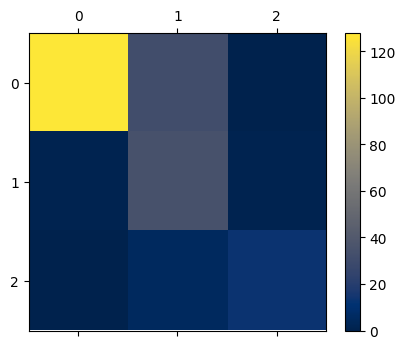

<Figure size 800x600 with 0 Axes>

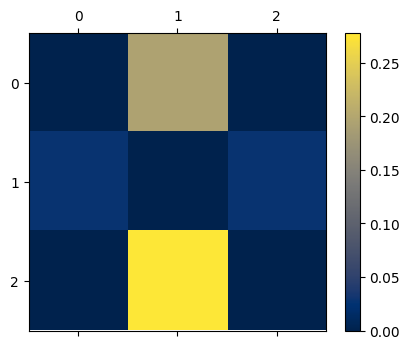

In [34]:
conf_mx = confusion_matrix(Ytest, ypred, labels = [1, 2, 3])
plt.figure(figsize=(8,8))
plt.matshow(conf_mx, cmap = 'cividis')
plt.colorbar(shrink=0.8)
plt.savefig('../results/ConfMatrixSVM.png')
plt.show()

row_sums = conf_mx.sum(axis=1, keepdims=True)
norm_conf_mx = conf_mx / row_sums
np.fill_diagonal(norm_conf_mx, 0)
plt.figure(figsize=(8,6))
plt.matshow(norm_conf_mx, cmap = 'cividis')
plt.colorbar(shrink = 0.8)
plt.savefig('../results/relativeConfSVM.png')
plt.show()

In [39]:
print(classification_report(Ytest, ypred).replace('      ', '&'))

&&  precision    recall  f1-score   support

&     1& 0.99&0.81&0.89& 159
&     2& 0.49&0.94&0.64&  36
&     3& 0.93&0.72&0.81&  18

    accuracy&&&&   0.82& 213
   macro avg& 0.80&0.82&0.78& 213
weighted avg& 0.90&0.82&0.84& 213

